In [1]:
import pandas as pd


In [2]:
df = pd.read_csv('dados_tratados.csv')

In [3]:
df.head()

,titulo,descricao,ocupacao,tarefa
0,0101-05 Oficial General da Aeronáutica - Briga...,"As funções deste grupo consistem em manter, cu...",10105,Abstrata
1,0101-10 Oficial General do Exército - General-...,"As funções deste grupo consistem em manter, cu...",10110,Abstrata
2,0101-15 Oficial General da Marinha - Almirante...,"As funções deste grupo consistem em manter, cu...",10115,Abstrata
3,0102-05 Oficial da Aeronáutica - Capitão; Coro...,Estão compreendidas nesta família ocupacional ...,10205,Abstrata
4,0102-10 Oficial do Exército - Capitão; Coronel...,Estão compreendidas nesta família ocupacional ...,10210,Abstrata


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2741 entries, 0 to 2740
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   titulo     2741 non-null   str  
 1   descricao  2741 non-null   str  
 2   ocupacao   2741 non-null   int64
 3   tarefa     2741 non-null   str  
dtypes: int64(1), str(3)
memory usage: 85.8 KB


In [5]:
%pip install unidecode nltk

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\abc.zip.
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping corpora\alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers\average

True

Criando bag of words

In [7]:
from sklearn.feature_extraction.text import CountVectorizer
vetorizar = CountVectorizer(lowercase=False, max_features=50)
bag_of_words = vetorizar.fit_transform(df.descricao)
print(bag_of_words.shape)

(2741, 50)


In [8]:
matriz_esparsa_avaliacoes = pd.DataFrame.sparse.from_spmatrix(bag_of_words, columns=vetorizar.get_feature_names_out())
matriz_esparsa_avaliacoes

,Podem,Preparam,Realizam,Trabalham,ambiental,ambiente,ao,as,atividades,clientes,...,qualidade,realizam,recursos,saúde,segurança,serviços,sistemas,trabalho,técnicos,área
0,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,1,0,0,0,0,1
1,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0,0,0,0,0,0,0,3,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,3,0,0,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2736,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2737,0,0,1,1,1,0,0,0,0,0,...,1,0,0,0,1,0,0,0,0,0
2738,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0
2739,0,0,1,0,0,1,1,0,0,0,...,1,0,0,0,1,2,1,0,1,0


In [9]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(bag_of_words, df.tarefa)

Primeira regressão para a bag of words

In [10]:
# A função multiclass não é mais usada
from sklearn.linear_model import LogisticRegression

regressao_multinomial = LogisticRegression(max_iter=1000)
regressao_multinomial.fit(x_treino, y_treino)
acuracia = regressao_multinomial.score(x_teste, y_teste)
print(f'Fazendo o primeiro teste para essa regressão multinomial temos a acuracia de: {acuracia * 100:.2f}%')

Fazendo o primeiro teste para essa regressão multinomial temos a acuracia de: 72.01%


In [11]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Primeira nuvem de palavras, sem tratamento nenhum

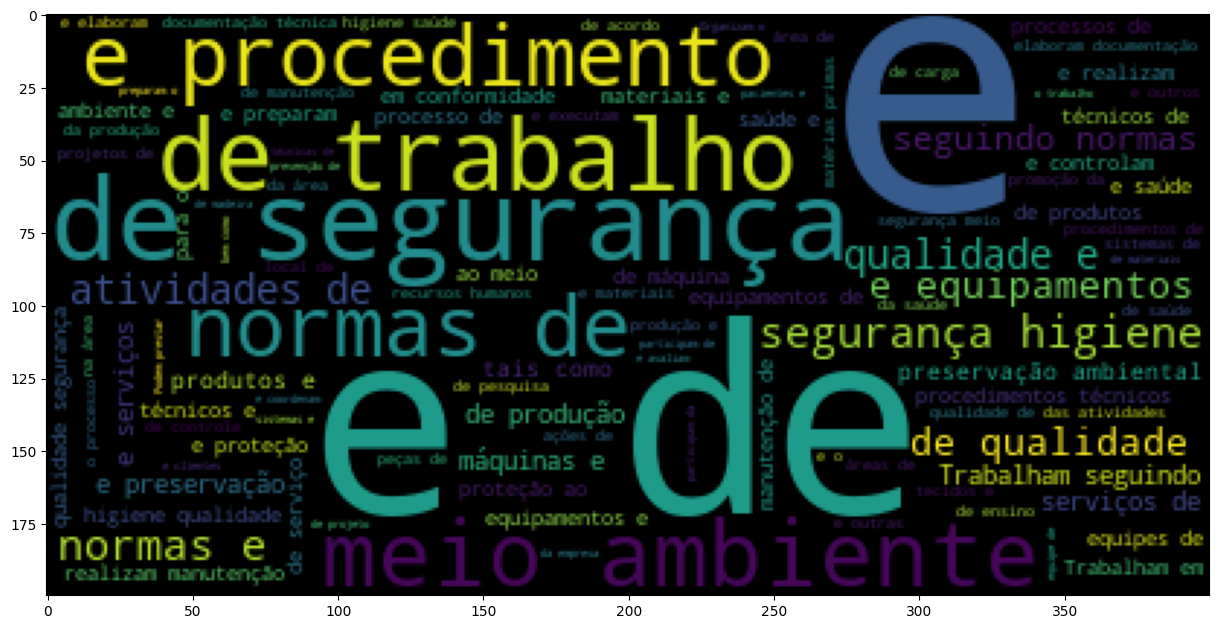

In [12]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

todas_palavras = [texto for texto in df.descricao]
todas_palavras = ' '.join([texto for texto in df.descricao])

nuvem_palavras = WordCloud().generate(todas_palavras)

plt.figure(figsize=(15, 10))
plt.imshow(nuvem_palavras)

In [13]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]

True

In [14]:
# Download specific NLTK data needed for RSLP stemmer
import nltk
nltk.download('stopwords')
nltk.download('rslp')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ECO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [15]:
import unidecode
import nltk
from nltk import tokenize

palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')
token_pontuacao = tokenize.WordPunctTokenizer()
stemmer = nltk.RSLPStemmer()

def processar_avaliacao(avaliacao):
  # Passo 1
  tokens = token_pontuacao.tokenize(avaliacao)

  # Passo 2
  frase_processada = [palavra for palavra in tokens if palavra.lower not in palavras_irrelevantes]

  # Passo 3
  frase_processada = [palavra for palavra in frase_processada if palavra.isalpha()]

  # Passo 4
  frase_processada = [unidecode.unidecode(palavra) for palavra in frase_processada]

  # Passo  5
  frase_processada = [stemmer.stem(palavra) for palavra in frase_processada]

  return ' '.join(frase_processada)

In [16]:
def nuvem_palavras(texto, coluna_texto, descricao):
    texto_descricao = texto.query(f'descricao == "{descricao}"')[coluna_texto]

    texto_unido = ' '.join(texto_descricao)
    nuvem_palavras = WordCloud(width=800, height=500, collocations=False)
    nuvem_palavras.generate(texto_unido)
    plt.figure(figsize=(15, 10))
    plt.imshow(nuvem_palavras, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [17]:
token_espaço = tokenize.WhitespaceTokenizer()
token_frase = token_espaço.tokenize(todas_palavras)
frequencia = nltk.FreqDist(token_frase)
frequencia.most_common(10)

[('e', 18057),
 ('de', 13332),
 ('a', 2166),
 ('em', 1980),
 ('para', 1633),
 ('o', 1609),
 ('da', 1554),
 ('do', 1167),
 ('atividades', 990),
 ('normas', 850)]

In [18]:
palavras_irrelevantes = nltk.corpus.stopwords.words('portuguese')

In [19]:
def classificar_texto(texto, coluna_texto, coluna_classificacao):
    vetorizar = CountVectorizer(lowercase=False, max_features=50)
    bag_of_words = vetorizar.fit_transform(texto[coluna_texto])
    X_treino, X_teste, y_treino, y_teste = train_test_split(bag_of_words, texto[coluna_classificacao], random_state=4978)
    regressao_logistica = LogisticRegression()
    regressao_logistica.fit(X_treino, y_treino)
    acuracia = regressao_logistica.score(X_teste, y_teste)
    return print(f"Acurácia do modelo com '{coluna_texto}': {acuracia * 100:.2f}%")

In [20]:
frase_processada = []

for descricao in df.descricao:
    palavras_texto = token_espaço.tokenize(descricao)
    nova_frase = [palavra for palavra in palavras_texto if palavra not in palavras_irrelevantes]
    frase_processada.append(' '.join(nova_frase))
  
df['tratamento_1'] = frase_processada

In [21]:
classificar_texto(df, 'tratamento_1', 'tarefa')

Acurácia do modelo com 'tratamento_1': 73.76%


In [22]:
frase_processada = []

for descricao in df['tratamento_1']:
  palavras_texto = token_pontuacao.tokenize(descricao)
  nova_frase = [palavra for palavra in palavras_texto if palavra.isalpha() and palavra not in palavras_irrelevantes]
  frase_processada.append(' '.join(nova_frase))

df['tratamento_2'] = frase_processada

In [23]:
classificar_texto(df, 'tratamento_2', 'tarefa')

Acurácia do modelo com 'tratamento_2': 73.76%


In [24]:
import seaborn as sns

def grafico_frequencia(texto, coluna_texto, quantidade):
    todas_palavras = ' '.join([texto for texto in texto[coluna_texto]])
    token_espaco = tokenize.WhitespaceTokenizer()
    frequencia = nltk.FreqDist(token_espaco.tokenize(todas_palavras))
    df_frequencia = pd.DataFrame({"Palavra": list(frequencia.keys()),
                                  "Frequência": list(frequencia.values())})
    df_frequencia = df_frequencia.nlargest(columns="Frequência", n=quantidade)

    plt.figure(figsize=(20,6))

    ax = sns.barplot(data=df_frequencia, x="Palavra", y ="Frequência", hue='Palavra', palette=sns.color_palette("mako", n_colors=quantidade))

    ax.set(ylabel="Contagem")
    plt.show()

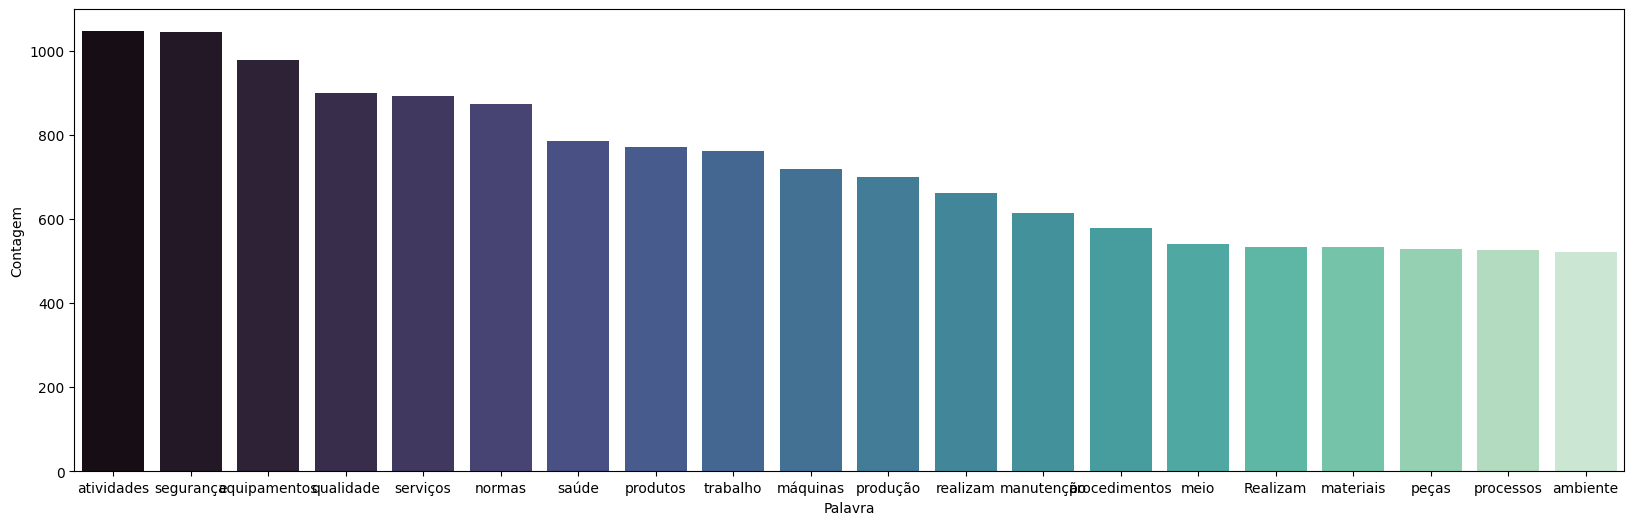

In [25]:
grafico_frequencia(df, 'tratamento_2', 20)

In [26]:
sem_acentos = [unidecode.unidecode(texto) for texto in df['tratamento_2']]
stopwords_sem_acento = [unidecode.unidecode(texto) for texto in palavras_irrelevantes]

In [27]:
df['tratamento_3'] = sem_acentos
frase_processada = []

for descricao in df['tratamento_3']:
  palavras_texto = token_pontuacao.tokenize(descricao)
  nova_frase = [palavra for palavra in palavras_texto if palavra not in stopwords_sem_acento]
  frase_processada.append(' '.join(nova_frase))

df['tratamento_3'] = frase_processada

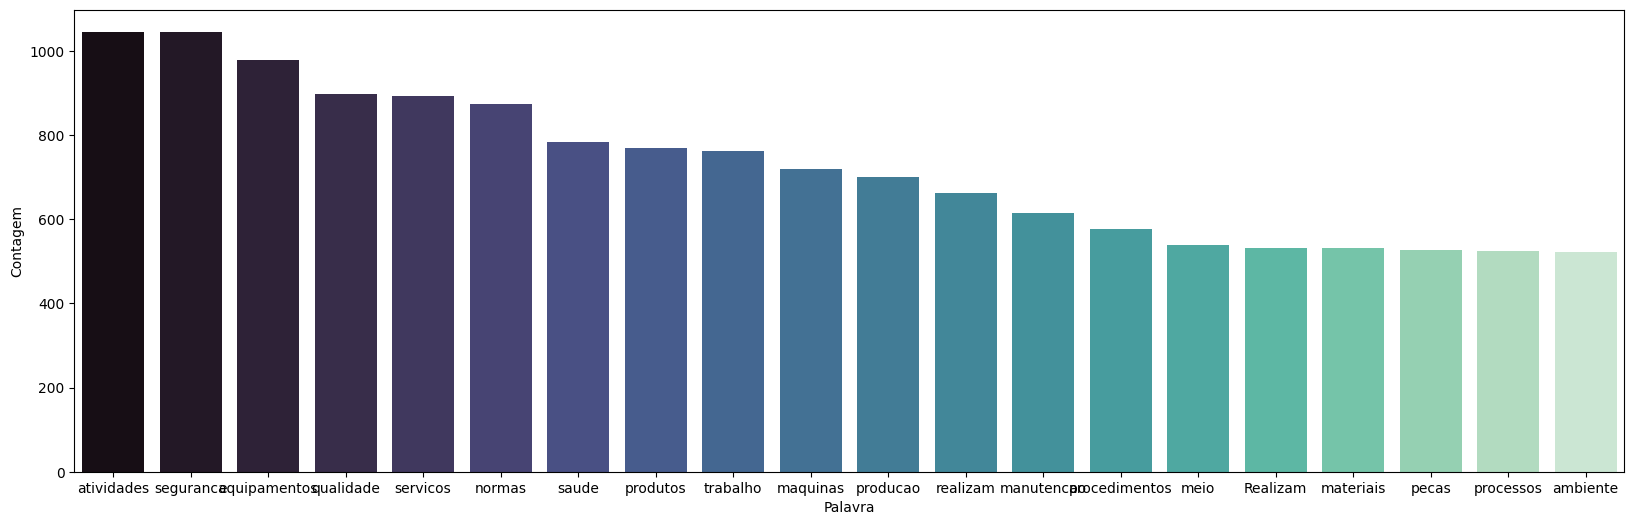

In [28]:
grafico_frequencia(df, 'tratamento_3', 20)

In [29]:
frase_processada =  []

for descricao in df['tratamento_3']:
  descricao = descricao.lower()
  palavras_texto = token_pontuacao.tokenize(descricao)
  nova_frase = [palavra for palavra in palavras_texto if palavra not in stopwords_sem_acento]
  frase_processada.append(' '.join(nova_frase))

df['tratamento_4'] = frase_processada

In [30]:
classificar_texto(df, 'tratamento_4', 'tarefa')

Acurácia do modelo com 'tratamento_4': 72.89%


In [31]:
stemmer = nltk.RSLPStemmer()

In [32]:
frase_processada = []

for descricao in df['tratamento_4']:
  palavras_texto = token_pontuacao.tokenize(descricao)
  nova_frase = [stemmer.stem(palavra) for palavra in palavras_texto]
  frase_processada.append(' '.join(nova_frase))

df['tratamento_5'] = frase_processada

In [33]:
classificar_texto(df, 'tratamento_5', 'tarefa')

Acurácia do modelo com 'tratamento_5': 74.05%


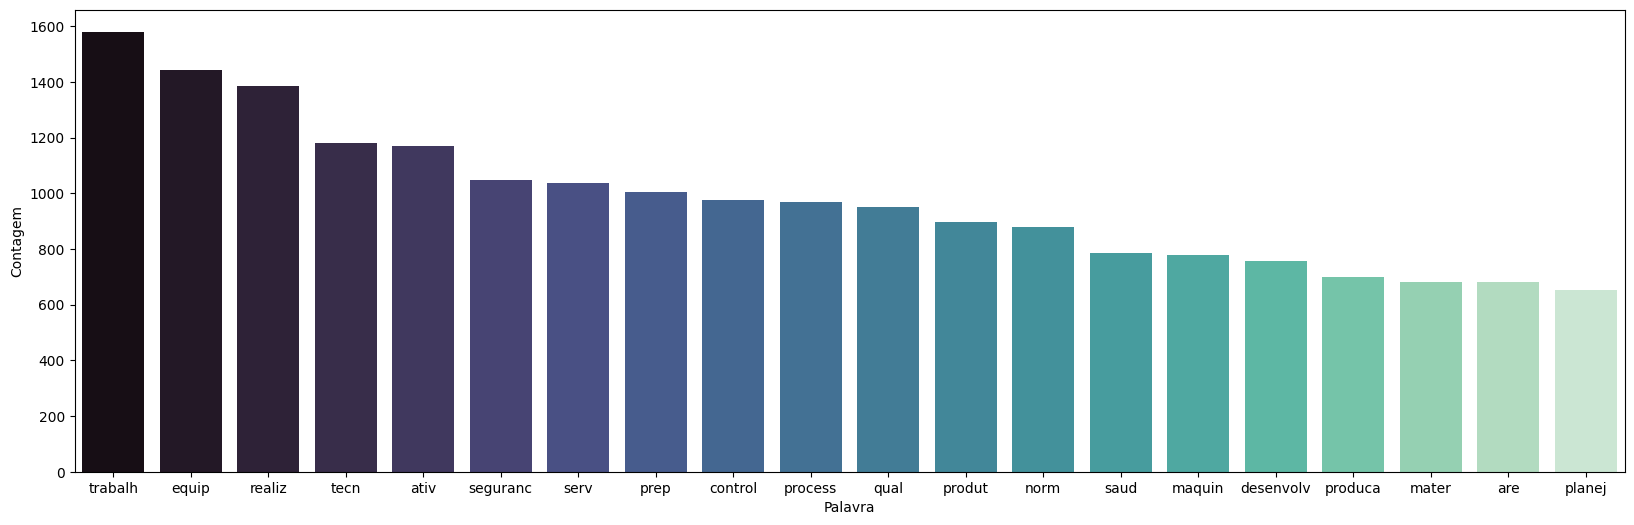

In [34]:
grafico_frequencia(df, 'tratamento_5', 20)

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(lowercase=False, max_features=50)

tfidf_bruto = tfidf.fit_transform(df["descricao"])
X_treino, X_teste, y_treino, y_teste = train_test_split(tfidf_bruto, df["tarefa"])
regressao_multinomial.fit(x_treino, y_treino)
acuracia_tfidf_bruto = regressao_multinomial.score(x_teste, y_teste)
print(f"Acurácia do modelo: {acuracia_tfidf_bruto *100:.2f}%")

Acurácia do modelo: 41.40%


In [36]:
tfidf_bruto = tfidf.fit_transform(df["descricao"])
X_treino, X_teste, y_treino, y_teste = train_test_split(tfidf_bruto, df["tarefa"])
regressao_multinomial.fit(x_treino, y_treino)
acuracia_tfidf_bruto = regressao_multinomial.score(x_teste, y_teste)
print(f"Acurácia do modelo: {acuracia_tfidf_bruto *100:.2f}%")

Acurácia do modelo: 39.36%


In [37]:
tfidf_tratados = tfidf.fit_transform(df['tratamento_5'])
X_treino, X_teste, y_treino, y_teste = train_test_split(tfidf_tratados, df['tarefa'])
regressao_multinomial.fit(X_treino, y_treino)
acuracia_tfidf_tratados = regressao_multinomial.score(X_teste, y_teste)
print(f'Acurácia do modelo: {acuracia_tfidf_tratados *100:.2f}%')

Acurácia do modelo: 76.38%


In [38]:
from nltk import ngrams

tfidf_50 = TfidfVectorizer(lowercase = False, max_features = 50, ngram_range=(1,2))
vetor_tfidf = tfidf_50.fit_transform(df['tratamento_5'])
x_treino, x_teste, y_treino, y_teste = train_test_split(vetor_tfidf, df['tarefa'])
regressao_multinomial.fit(x_treino, y_treino)
acuracia_tfidf_50 = regressao_multinomial.score(x_teste, y_teste)
print(f'Acuracia do modelo: {acuracia_tfidf_50 * 100:.2f}%')

Acuracia do modelo: 75.66%


In [39]:
tfidf_1000 = TfidfVectorizer(lowercase = False, max_features = 1000, ngram_range=(1,2))
vetor_tfidf = tfidf_1000.fit_transform(df['tratamento_5'])
x_treino, x_teste, y_treino, y_teste = train_test_split(vetor_tfidf, df['tarefa'], random_state=4979)
regressao_multinomial.fit(x_treino, y_treino)
acuracia_tfidf_1000 = regressao_multinomial.score(x_teste, y_teste)
print(f'Acuracia do modelo: {acuracia_tfidf_1000 * 100:.2f}%')

Acuracia do modelo: 92.57%


In [40]:
pesos = pd.DataFrame(
    regressao_multinomial.coef_[0].T,
    index=tfidf_1000.get_feature_names_out()
)

In [41]:
pesos.nlargest(10, 0)

,0
projet,2.497119
desenvolv,2.347795
gerenc,1.912534
sistem,1.576665
coorden,1.544775
pesquis,1.527348
recurs,1.420319
dirig,1.413669
conhec,1.317727
biolog,1.317355


In [42]:
pesos.nsmallest(10, 0)

,0
vend,-1.666739
control,-1.610486
local,-1.478831
prep,-1.471425
seguranc,-1.198532
norm seguranc,-1.184238
metal,-1.166277
veicul,-1.126114
pec,-1.121472
segu,-1.104669


In [43]:
def classificacao(posicao):

  sample_index = y_teste.index[posicao]
  print("=" * 50)
  print(f"Posição Original: {sample_index}")
  print("=" * 50)
  print(f"Titulo: {df.loc[sample_index, 'titulo']}")
  print("=" * 50)
  print(f"Descricao: {df.loc[sample_index, 'descricao']}")
  print("=" * 50)
  proba = regressao_multinomial.predict_proba(x_teste[posicao])
  print("=" * 50)
  print(f"Classes: {regressao_multinomial.classes_}")
  print("=" * 50)
  print(f"Probabilities: {proba}")
  print("=" * 50)

In [44]:
classificacao(1)

Posição Original: 1928
Titulo: 7661-20 Editor de texto e imagem - Arte-finalista; Diagramador (jornalismo) Dia- gramador e desenhista; Diagramador em terminal de vídeo; Especialista em arte final;  Montador de arte final.
Descricao: Planejam serviços da impressão gráfica e ajustam máquinas para impressão. Realizam serviços da impressão gráfica, tais como impressão plana e rotativa, impressão di- gital, flexografia, litografia, tipografia, letterset, calcografia, tampografia, rotogravura e serigrafia (silks-creen). Trabalham seguindo normas e procedimentos técnicos e de qualidade, segurança, meio ambiente, higiene e saúde.
Classes: ['Abstrata' 'Manual' 'R. Cognitiva' 'R. Manual']
Probabilities: [[0.03974132 0.05295071 0.01652854 0.89077943]]


Recalculando vetores de IF-IDF

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_1000 = TfidfVectorizer(lowercase=False, max_features=1000, ngram_range=(1,2))
vetor_tfidf = tfidf_1000.fit_transform(df['tratamento_5'])
print("recalculado vetores de IF-IDF.")

recalculado vetores de IF-IDF.


In [46]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(vetor_tfidf, df['tarefa'], random_state=4979)
print("Separação de teste e treino bem sucedida.")

Separação de teste e treino bem sucedida.


In [47]:
regressao_multinomial.fit(x_treino, y_treino)
print("Regressão logística multinomial treinada com sucesso.")

Regressão logística multinomial treinada com sucesso.


In [48]:
y_pred = regressao_multinomial.predict(x_teste)
print("Predições feitas com sucesso.")

Predições feitas com sucesso.


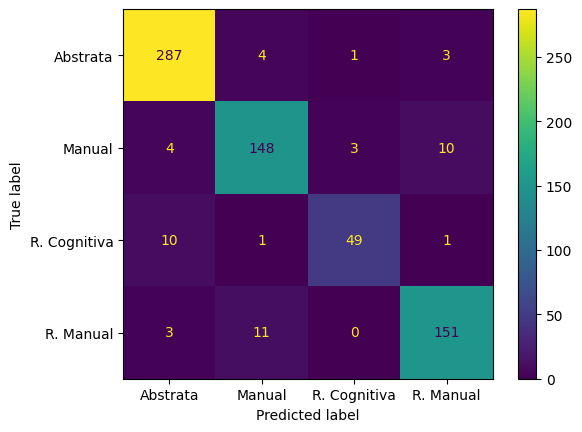

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_teste, y_pred), display_labels=regressao_multinomial.classes_).plot()
plt.grid(False)
plt.show()

In [50]:
# Ocupações que foram confundidas

misclassified_indices = y_teste.index[y_teste != y_pred]

misclassified_titles = df.loc[misclassified_indices, 'titulo']
print("Classificados errados:")
display(misclassified_titles)

Classificados errados:


1865    7618-05 Inspetor de estamparia (produção têxti...
2374      9152-15 Luthier (restauração de cordas arcadas)
1150    4223-20 Operador de telemarketing técnico - Op...
1713    7252-15 Montador de máquinas operatrizes para ...
2026                      7772-05 Carpinteiro de carretas
2385    9501-10 Supervisor de manutenção eletromecânic...
929     3514-25 Oficial de justiça - Oficial judiciári...
1516       7112-45 Operador de trator (minas e pedreiras)
2373    9152-10 Reparador de instrumentos musicais - A...
868                      3253-05 Técnico em biotecnologia
945     3518-15 Papiloscopista policial - Datiloscopis...
985     3712-05 Colecionador de selos e moedas - Numis...
26                          0312-05 Cabo Bombeiro Militar
609                    2541-10 Técnico da receita federal
2350    9112-05 Mecânico de manutenção e instalação de...
869                    3253-10 Técnico em imunobiológicos
2312    8601-15 Supervisor de operação elétrica (geraç...
1147    4223-0

In [51]:
print(acuracia_tfidf_1000)

0.9256559766763849


In [52]:
def classificar_ifidf(random_state):
    tfidf_1000 = TfidfVectorizer(lowercase = False, max_features = 1000, ngram_range=(1,2))
    vetor_tfidf = tfidf_1000.fit_transform(df['tratamento_5'])
    x_treino, x_teste, y_treino, y_teste = train_test_split(vetor_tfidf, df['tarefa'], random_state=random_state)
    regressao_multinomial.fit(x_treino, y_treino)
    acuracia_tfidf_1000 = regressao_multinomial.score(x_teste, y_teste)

    return acuracia_tfidf_1000  
print(f'Acuracia do modelo: {acuracia_tfidf_1000 * 100:.2f}%')

Acuracia do modelo: 92.57%


In [53]:
for i in range(300):
    acuracia = classificar_ifidf(random_state=i)
    if acuracia > 0.95: 
        print(f"Random State: {i} - Acurácia: {acuracia * 100:.2f}% - Acurácia acima de 95%")

Random State: 1 - Acurácia: 95.19% - Acurácia acima de 95%
Random State: 4 - Acurácia: 95.04% - Acurácia acima de 95%
Random State: 9 - Acurácia: 95.04% - Acurácia acima de 95%
Random State: 76 - Acurácia: 95.63% - Acurácia acima de 95%
Random State: 97 - Acurácia: 95.04% - Acurácia acima de 95%
Random State: 106 - Acurácia: 95.19% - Acurácia acima de 95%
Random State: 109 - Acurácia: 95.04% - Acurácia acima de 95%
Random State: 127 - Acurácia: 95.19% - Acurácia acima de 95%
Random State: 142 - Acurácia: 95.34% - Acurácia acima de 95%
Random State: 165 - Acurácia: 95.04% - Acurácia acima de 95%
Random State: 172 - Acurácia: 95.34% - Acurácia acima de 95%
Random State: 198 - Acurácia: 95.34% - Acurácia acima de 95%
Random State: 230 - Acurácia: 95.04% - Acurácia acima de 95%
Random State: 261 - Acurácia: 95.04% - Acurácia acima de 95%
Random State: 265 - Acurácia: 95.19% - Acurácia acima de 95%
Random State: 291 - Acurácia: 95.92% - Acurácia acima de 95%


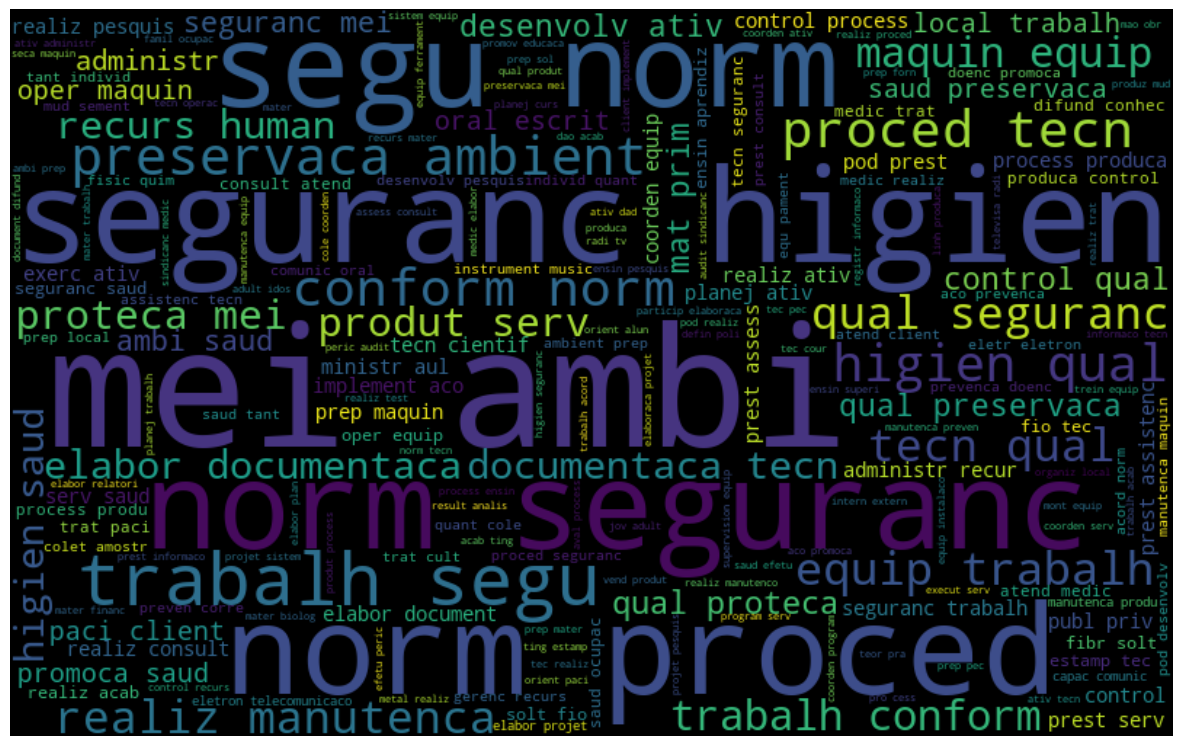

In [54]:
# Nuvem de palavras para tratamento_5
todas_palavras_tratamento5 = ' '.join([texto for texto in df.tratamento_5])

nuvem_tratamento5 = WordCloud(width=800, height=500, colormap='viridis')
nuvem_tratamento5.generate(todas_palavras_tratamento5)

plt.figure(figsize=(15, 10))
plt.imshow(nuvem_tratamento5, interpolation='bilinear')
plt.axis('off')
plt.show()

In [58]:
def agradação_das_tarefas(descricao, ocupacao):

    nova_descricao_processada = processar_avaliacao(descricao)

    nova_descricao_tfidf = tfidf_1000.transform([nova_descricao_processada])

    probabilidades = regressao_multinomial.predict_proba(nova_descricao_tfidf)
    predicao = regressao_multinomial.predict(nova_descricao_tfidf)

    print(f"Ocupação prevista para a ocupação '{ocupacao}': {predicao[0]}")
    print(f"Descrição processada: {probabilidades[0].max() * 100:.2f}%")
    classes = regressao_multinomial.classes_
    probabilidades_dict = {classe: prob for classe, prob in zip(classes, probabilidades[0])}
    resultado_df = pd.DataFrame([probabilidades_dict]).T.sort_values(0, ascending=False)

    print("\nProbabilidades por ocupação:")
    print(resultado_df)

In [59]:
desc = df['descricao'].iloc[0]
ocupacao = df['titulo'].iloc[0]
agradação_das_tarefas(desc, ocupacao)

Ocupação prevista para a ocupação '0101-05 Oficial General da Aeronáutica - Brigadeiro; Major-brigadeiro; Marechal- do-ar; Tenente-brigadeiro.': Abstrata
Descrição processada: 74.74%

Probabilidades por ocupação:
                     0
Abstrata      0.747383
Manual        0.116616
R. Cognitiva  0.094385
R. Manual     0.041616
